Optimization & Training Dynamics
**Batch Normalization**, **Learning Rate** **Optimizer (SGD vs Adam)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
# 1. Veri Yükleme (Önceki üyelerin hazırladığı veri formatı)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_data, val_data = random_split(train_full, [50000, 10000])
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

In [2]:
# 2. Modele Batch Normalization Eklenmesi
class OptimizedMLP(nn.Module):
    def __init__(self, activation_fn=nn.ReLU()):
        super(OptimizedMLP, self).__init__()
        self.flatten = nn.Flatten()
        
        # Linear -> BatchNorm -> Activation
        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512)
        
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        
        self.fc5 = nn.Linear(64, 10)
        self.activation = activation_fn
        
        # Member 3'ün Regulariation adımı (Dropout)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.activation(self.bn1(self.fc1(x))))
        x = self.dropout(self.activation(self.bn2(self.fc2(x))))
        x = self.dropout(self.activation(self.bn3(self.fc3(x))))
        x = self.dropout(self.activation(self.bn4(self.fc4(x))))
        x = self.fc5(x)
        return x

In [3]:
# 3. Eğitim Fonksiyonu
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    train_losses = []
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
    return train_losses

In [4]:
# 4. Optimizasyon Deneyleri (SGD vs Adam & Learning Rates)
learning_rates = [0.1, 0.01, 0.001]
optimizers_to_test = ['SGD', 'Adam']
optimization_results = {}

for opt_name in optimizers_to_test:
    for lr in learning_rates:
        print(f"\n--- Eğitiliyor: {opt_name} | LR: {lr} ---")
        
        model = OptimizedMLP(nn.ReLU()).to(device)
        criterion = nn.CrossEntropyLoss()
        
        if opt_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=lr)
        else:
            optimizer = optim.Adam(model.parameters(), lr=lr)
            
        losses = train_model(model, train_loader, criterion, optimizer, epochs=5)
        optimization_results[f"{opt_name}_LR_{lr}"] = losses
        
print("\nTüm eğitim koşuları başarıyla tamamlandı.")


--- Eğitiliyor: SGD | LR: 0.1 ---

--- Eğitiliyor: SGD | LR: 0.01 ---

--- Eğitiliyor: SGD | LR: 0.001 ---

--- Eğitiliyor: Adam | LR: 0.1 ---

--- Eğitiliyor: Adam | LR: 0.01 ---

--- Eğitiliyor: Adam | LR: 0.001 ---

Tüm eğitim koşuları başarıyla tamamlandı.


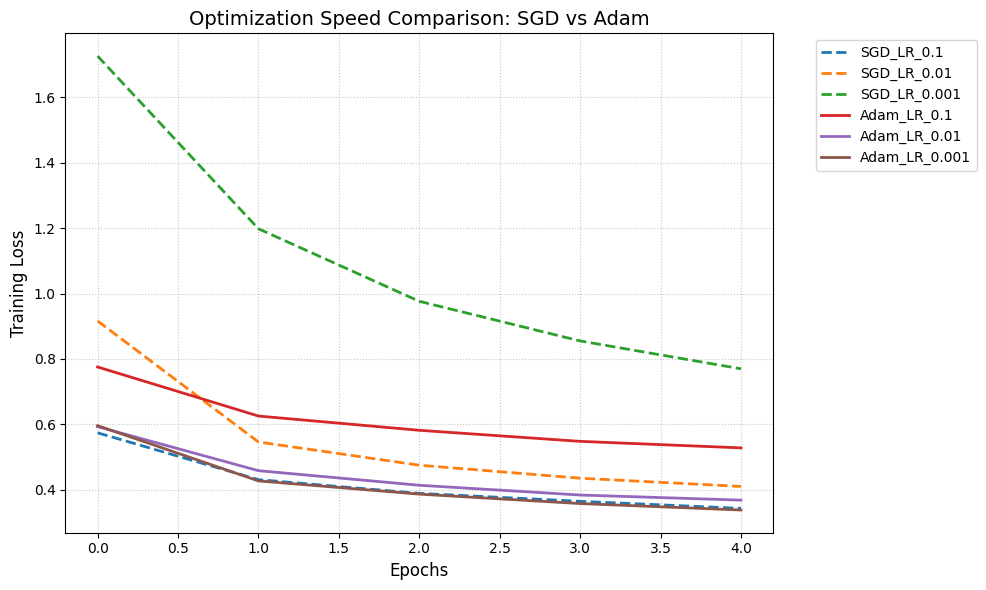

In [5]:
# 5. Optimizasyon Kıyaslama Grafiklerini Çizdirme
plt.figure(figsize=(10, 6))
for key, losses in optimization_results.items():
    if 'Adam' in key:
        linestyle = '-'
    else:
        linestyle = '--'
    plt.plot(losses, label=key, linestyle=linestyle, linewidth=2)

plt.title('Optimization Speed Comparison: SGD vs Adam', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()